In [1]:
#load all packages
import numpy as np
import random
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


2026-03-18 21:58:15.563914: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#read in data
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [3]:
#explore data 
print(X_train.shape)
print(y_train.shape)
print(X_train.dtypes)
print(X_train.columns)
X_train.head()

(148883, 17)
(148883, 1)
Age                      int64
Gender                     str
Country                    str
Ethnicity                  str
Family_History             str
Radiation_Exposure         str
Iodine_Deficiency          str
Smoking                    str
Obesity                    str
Diabetes                   str
TSH_Level              float64
T3_Level               float64
T4_Level               float64
Nodule_Size            float64
Risk_Factor_Score        int64
TSH_Nodule_Interact    float64
T3_TSH_Ratio           float64
dtype: object
Index(['Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Risk_Factor_Score', 'TSH_Nodule_Interact', 'T3_TSH_Ratio'],
      dtype='str')


,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Risk_Factor_Score,TSH_Nodule_Interact,T3_TSH_Ratio
0,49,Male,UK,Middle Eastern,Yes,No,No,No,No,No,0.59,0.66,6.97,0.01,1,0.0059,1.118644
1,80,Male,India,Caucasian,Yes,No,No,No,No,No,8.65,1.27,11.71,1.65,1,14.2725,0.146821
2,73,Male,India,Asian,No,Yes,Yes,No,Yes,No,0.70,2.42,7.84,0.93,3,0.6510,3.457143
3,46,Female,China,Caucasian,No,Yes,Yes,Yes,No,No,7.76,0.78,8.83,0.68,3,5.2768,0.100515
4,29,Male,Brazil,African,No,No,Yes,No,No,No,4.14,3.28,11.39,1.70,1,7.0380,0.792271


In [4]:
#encode categorical into dummy variables
binary_cols = ['Gender', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']
multi_cols = ['Country','Ethnicity', 'Risk_Factor_Score']
le = LabelEncoder()
for col in binary_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

y_train['Diagnosis'] = le.fit_transform(y_train['Diagnosis'])
y_test['Diagnosis'] = le.transform(y_test['Diagnosis'])


X_train = pd.get_dummies(X_train, columns=multi_cols)
X_test = pd.get_dummies(X_test, columns=multi_cols)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [5]:
#convert into arrays and then make 1D for cross validation
X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32).ravel()
y_test = np.array(y_test, dtype=np.float32).ravel()
print(X_train.shape)

#scale the data to center around zero 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(148883, 36)


In [6]:
#determine best hyperparameters 

param_grid = [
    {'neurons1': 64,  'neurons2': 32, 'dropout': 0.2},
    {'neurons1': 128, 'neurons2': 64, 'dropout': 0.2},
    {'neurons1': 64,  'neurons2': 32, 'dropout': 0.3},
    {'neurons1': 128, 'neurons2': 64, 'dropout': 0.3},
    {'neurons1': 32,  'neurons2': 16, 'dropout': 0.1},
]

In [7]:
#set up 5 fold cross validation 
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_features = X_train.shape[1]
best_mean_auc = 0
best_params = None
all_results = []


oof_predictions = np.zeros_like(y_train, dtype=float)
for params in param_grid:
    print('===========================================')
    print(f"Trying: neurons=({params['neurons1']},{params['neurons2']}) dropout={params['dropout']}")
    print('===========================================')
    fold_accuracies = []
    fold_aucs = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_num = 1

    for train_idx, val_idx in kfold.split(X_train, y_train):
        print(f"\n-- Fold {fold_num}/5 --")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = keras.Sequential([
            keras.layers.Input(shape=(n_features,)),
            keras.layers.Dense(params['neurons1'], activation='relu'),
            keras.layers.Dropout(params['dropout']),
            keras.layers.Dense(params['neurons2'], activation='relu'),
            keras.layers.Dropout(params['dropout']),
            keras.layers.Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

        model.fit(X_tr, y_tr,
                epochs=10,
                batch_size=512,
                verbose=0)

        # get probabilities then convert to 0/1 predictions
        y_pred_prob = model.predict(X_val, verbose=0).flatten()
        oof_predictions[val_idx] = y_pred_prob
        y_pred = (y_pred_prob > 0.5).astype(int)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        auc  = roc_auc_score(y_val, y_pred_prob)
        prec = precision_score(y_val, y_pred)
        rec  = recall_score(y_val, y_pred)
        f1   = f1_score(y_val, y_pred)

        print(f"Accuracy:  {acc:.2%}")
        print(f"Precision: {prec:.2%}")
        print(f"Recall:    {rec:.2%}")
        print(f"F1 Score:  {f1:.2%}")
        print(f"AUC-ROC:   {auc:.3f}")

        fold_accuracies.append(acc)
        fold_aucs.append(auc)
        fold_precisions.append(prec)
        fold_recalls.append(rec)
        fold_f1s.append(f1)
        fold_num += 1
        

    print(f"\n{'='*35}")
    print(f"Mean Accuracy:  {np.mean(fold_accuracies):.2%} (+/- {np.std(fold_accuracies):.2%})")
    print(f"Mean Precision: {np.mean(fold_precisions):.2%} (+/- {np.std(fold_precisions):.2%})")
    print(f"Mean Recall:    {np.mean(fold_recalls):.2%} (+/- {np.std(fold_recalls):.2%})")
    print(f"Mean F1 Score:  {np.mean(fold_f1s):.2%} (+/- {np.std(fold_f1s):.2%})")
    print(f"Mean AUC-ROC:   {np.mean(fold_aucs):.3f} (+/- {np.std(fold_aucs):.3f})")
    mean_auc = np.mean(fold_aucs)
    all_results.append({'params': params, 'mean_auc': mean_auc,
                        'mean_f1': np.mean(fold_f1s), 'mean_recall': np.mean(fold_recalls)})
    if mean_auc > best_mean_auc:
        best_mean_auc = mean_auc
        best_params = params


print(f"\n{'='*45}")
print(f"BEST PARAMS: neurons=({best_params['neurons1']},{best_params['neurons2']}) dropout={best_params['dropout']}")
print(f"BEST MEAN AUC: {best_mean_auc:.3f}")

Trying: neurons=(64,32) dropout=0.2

-- Fold 1/5 --
Accuracy:  82.68%
Precision: 69.99%
Recall:    44.83%
F1 Score:  54.65%
AUC-ROC:   0.693

-- Fold 2/5 --
Accuracy:  82.58%
Precision: 69.52%
Recall:    44.81%
F1 Score:  54.50%
AUC-ROC:   0.695

-- Fold 3/5 --
Accuracy:  82.96%
Precision: 70.69%
Recall:    45.82%
F1 Score:  55.60%
AUC-ROC:   0.698

-- Fold 4/5 --
Accuracy:  82.81%
Precision: 70.61%
Recall:    44.81%
F1 Score:  54.83%
AUC-ROC:   0.696

-- Fold 5/5 --
Accuracy:  82.84%
Precision: 70.52%
Recall:    45.15%
F1 Score:  55.05%
AUC-ROC:   0.697

Mean Accuracy:  82.78% (+/- 0.13%)
Mean Precision: 70.27% (+/- 0.45%)
Mean Recall:    45.08% (+/- 0.39%)
Mean F1 Score:  54.92% (+/- 0.38%)
Mean AUC-ROC:   0.696 (+/- 0.002)
Trying: neurons=(128,64) dropout=0.2

-- Fold 1/5 --
Accuracy:  82.67%
Precision: 69.94%
Recall:    44.78%
F1 Score:  54.60%
AUC-ROC:   0.696

-- Fold 2/5 --
Accuracy:  82.59%
Precision: 69.54%
Recall:    44.83%
F1 Score:  54.51%
AUC-ROC:   0.696

-- Fold 3/5 --
A

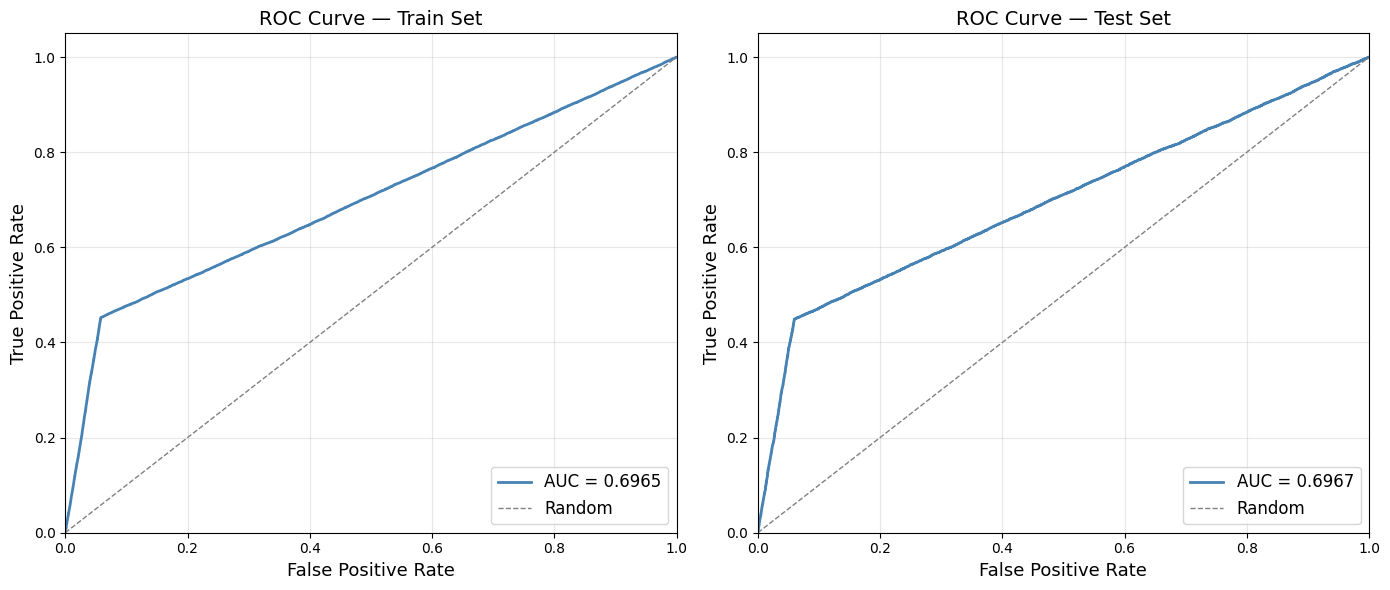

Metric for Best Neural Network on Test Set
Accuracy:  0.8259
Precision: 0.6946
Recall:    0.4485
F1 Score:  0.5451
AUC-ROC:   0.6967


In [8]:
#save results 
#set the seed
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
# get probabilities from final model
X_tr, X_val = X_train, X_train
y_tr, y_val = y_train, y_train
final_model = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(best_params['neurons1'], activation='relu'),
    keras.layers.Dropout(best_params['dropout']),
    keras.layers.Dense(best_params['neurons2'], activation='relu'),
    keras.layers.Dropout(best_params['dropout']),
    keras.layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

final_model.fit(X_tr, y_tr,
                epochs=10,
                batch_size=512,
                verbose=0)

y_pred_prob = final_model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

y_prob_train = final_model.predict(X_train, verbose=0).flatten()
y_prob_test  = final_model.predict(X_test, verbose=0).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (split, y_true, y_prob) in zip(axes, [
    ("Train", y_train, oof_predictions),
    ("Test",  y_test,  y_prob_test),
]):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.set_title(f"ROC Curve — {split} Set", fontsize=14)
    ax.legend(loc="lower right", fontsize=12)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/best_nn_tara_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

_, acc = final_model.evaluate(X_test, y_test, verbose=0)
auc  = roc_auc_score(y_test, y_pred_prob)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("="*45)
print("Metric for Best Neural Network on Test Set")
print("="*45)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
